<div style="background-color:#84bfef; padding:20px; border-radius:10px">

# Desafío #1 | Equipo 31 | Análisis de Absentismo y Bienestar Laboral
</div>

Este notebook responde la pregunta de negocio del perfil **Analista de Absentismo y Bienestar Laboral**:

> ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año? 
> ¿Cómo podemos anticiparnos para reforzar la planificación de recursos humanos y garantizar la continuidad operativa?

El análisis explora los registros disponibles para preparar conclusiones de negocio y materiales de dashboard/presentación.


## 1. Enfoque del análisis

Se trabaja con registros de solicitudes o comunicaciones de ausencia asociados a empleados (`ID`). Como un ID puede aparecer muchas veces, se distinguen dos niveles:

- **Registro:** fila individual del dataset; útil para meses, días, motivos y horas.
- **ID registrado:** código de empleado presente en el dataset; útil para medir concentración y carga acumulada dentro de los registros disponibles.

El dataset no indica si las solicitudes fueron aprobadas ni si incluye a toda la plantilla. 
Por tanto, los resultados describen los registros disponibles y no deben interpretarse como absentismo efectivo total de la empresa.


## 2. Librerías y configuración


In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.facecolor"] = "none"
plt.rcParams["axes.facecolor"] = "none"
plt.rcParams["savefig.facecolor"] = "none"
plt.rcParams["savefig.transparent"] = True
COLOR_PRINCIPAL = "#2F6F73"
COLOR_SECUNDARIO = "#D68C45"
COLOR_ALERTA = "#B94E48"
COLOR_GRIS = "#6B7280"


## 3. Carga de datos


In [2]:
DATA_FILE = '../../Data/clean/clean_data_25052026.csv'
RRHH = pd.read_csv(DATA_FILE)

print("Archivo cargado:", DATA_FILE)
print("Dimensiones:", RRHH.shape)
RRHH.head()


Archivo cargado: ../../Data/clean/clean_data_25052026.csv
Dimensiones: (740, 27)


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
0,14,11.00,Sistema digestivo,11.00,Noviembre,2,Lunes,2,Primavera,155,12,14,34,284.03,97,0,1,Secundaria,2,1,0,0,95,196,25,24.70,120
1,36,13.00,Sistema musculoesquelético,4.00,Abril,4,Miércoles,4,Otoño,118,13,18,50,239.41,98,0,1,Secundaria,1,1,0,0,98,178,31,30.90,120
2,9,6.00,Sistema nervioso,7.00,Julio,3,Martes,1,Invierno,228,14,16,58,264.60,93,0,1,Secundaria,2,0,0,1,65,172,22,22.00,120
3,28,9.00,Sistema circulatorio,7.00,Julio,3,Martes,1,Invierno,225,26,9,28,230.29,92,0,1,Secundaria,1,0,0,2,69,169,24,24.20,112
4,9,12.00,Piel y tejido subcutáneo,3.00,Marzo,3,Martes,3,Verano,228,14,16,58,222.20,99,0,1,Secundaria,2,0,0,1,65,172,22,22.00,112


## 4. Preparación analítica


In [3]:
df_clean = RRHH.copy()
df_clean["Tiene_ausencia"] = df_clean["Absenteeism_hours"] > 0

filas_duplicadas = df_clean.duplicated().sum()
df_abs = df_clean[df_clean["Absenteeism_hours"] > 0].copy()
df_temporal = df_clean[df_clean["Month_absence"].notna()].copy()

resumen_preparacion = pd.DataFrame({
    "métrica": [
        "registros_originales",
        "duplicados_exactos_detectados",
        "registros_para_análisis",
        "registros_con_ausencia_>_0h",
        "registros_con_0h",
        "empleados_ID_únicos",
        "empleados_con_ausencia_>_0h",
    ],
    "valor": [
        len(RRHH),
        filas_duplicadas,
        len(df_clean),
        len(df_abs),
        (df_clean["Absenteeism_hours"] == 0).sum(),
        df_clean["ID"].nunique(),
        df_abs["ID"].nunique(),
    ]
})

resumen_preparacion


,métrica,valor
0,registros_originales,740
1,duplicados_exactos_detectados,34
2,registros_para_análisis,740
3,registros_con_ausencia_>_0h,696
4,registros_con_0h,44
5,empleados_ID_únicos,36
6,empleados_con_ausencia_>_0h,33


**Decisión metodológica:** el análisis parte de `clean_data_25052026.csv`, generado por `Data_cleaning_25052026.ipynb`. No se eliminan filas adicionales en este notebook; los cálculos se hacen sobre el dataset limpio tal como queda después de la fase de limpieza.

## 5. KPI principales de absentismo


In [4]:
total_ids = df_clean["ID"].nunique()
ids_con_ausencia = df_abs["ID"].nunique()
horas_totales = df_clean["Absenteeism_hours"].sum()
registros_ausencia = len(df_abs)
horas_medias_registro = df_abs["Absenteeism_hours"].mean()
horas_medias_id = df_clean.groupby("ID")["Absenteeism_hours"].sum().mean()
mediana_horas_id = df_clean.groupby("ID")["Absenteeism_hours"].sum().median()

kpi_absentismo = pd.DataFrame({
    "KPI": [
        "IDs únicos en los registros",
        "IDs con al menos un registro de ausencia > 0h",
        "% IDs del dataset con ausencia > 0h",
        "Registros de ausencia > 0h",
        "Horas totales registradas",
        "Media de horas por registro con ausencia",
        "Media de horas acumuladas por ID",
        "Mediana de horas acumuladas por ID",
    ],
    "Valor": [
        total_ids,
        ids_con_ausencia,
        f"{ids_con_ausencia / total_ids * 100:.1f}%",
        registros_ausencia,
        horas_totales,
        round(horas_medias_registro, 2),
        round(horas_medias_id, 2),
        round(mediana_horas_id, 2),
    ],
})

kpi_absentismo


,KPI,Valor
0,IDs únicos en los registros,36
1,IDs con al menos un registro de ausencia > 0h,33
2,% IDs del dataset con ausencia > 0h,91.7%
3,Registros de ausencia > 0h,696
4,Horas totales registradas,5124
5,Media de horas por registro con ausencia,7.36
6,Media de horas acumuladas por ID,142.33
7,Mediana de horas acumuladas por ID,78.00


## 6. KPI según fórmulas del desafío

Esta sección replica explícitamente las **3 fórmulas solicitadas** para absentismo. Se calcula sobre la vista depurada.

- **Porcentaje de IDs con ausencia (%):** IDs con al menos un registro de más de 0 horas / IDs totales presentes en el dataset.
- **Mes pico de carga por ausencias:** mes con mayor suma de horas registradas.
- **Motivo modal de absentismo laboral:** motivo con mayor frecuencia de registros.

Estas fórmulas describen los registros disponibles. Para calcular una tasa real de la empresa **haría falta conocer la plantilla completa y confirmar qué solicitudes fueron aprobadas.**


In [5]:
numero_total_ids = df_clean["ID"].nunique()
numero_ids_ausentes = df_abs["ID"].nunique()
porcentaje_empleados_ausentes = numero_ids_ausentes / numero_total_ids * 100

horas_por_mes_formula = df_temporal.groupby(["Month_absence", "Month_absence_name"], as_index=False)["Absenteeism_hours"].sum()
horas_por_mes_formula = horas_por_mes_formula.rename(columns={"Absenteeism_hours": "horas_absentismo"})
mes_pico_formula = horas_por_mes_formula.sort_values("horas_absentismo", ascending=False).iloc[0]

frecuencia_por_motivo_formula = df_abs.groupby(["Reason_absence", "Reason_absence_name"], as_index=False).size()
frecuencia_por_motivo_formula = frecuencia_por_motivo_formula.rename(columns={"size": "frecuencia"})
motivo_modal_formula = frecuencia_por_motivo_formula.sort_values("frecuencia", ascending=False).iloc[0]

kpi_formulas_desafio = pd.DataFrame({
    "KPI": [
        "Porcentaje de IDs con ausencia (%)",
        "Mes pico de carga por ausencias",
        "Motivo modal de absentismo laboral",
    ],
    "Resultado": [
        f"{porcentaje_empleados_ausentes:.1f}% ({numero_ids_ausentes}/{numero_total_ids})",
        f"{mes_pico_formula['Month_absence_name']} ({mes_pico_formula['horas_absentismo']:.0f} horas)",
        f"{int(motivo_modal_formula['Reason_absence'])} - {motivo_modal_formula['Reason_absence_name']} ({int(motivo_modal_formula['frecuencia'])} registros)",
    ],
    "Lectura de negocio": [
        "Mide la extensión de los registros entre los IDs presentes en el dataset.",
        "Identifica el mes que requiere más atención por volumen de horas registradas.",
        "Identifica el motivo que más se repite en los registros.",
    ]
})

kpi_formulas_desafio


,KPI,Resultado,Lectura de negocio
0,Porcentaje de IDs con ausencia (%),91.7% (33/36),Mide la extensión de los registros entre los I...
1,Mes pico de carga por ausencias,Marzo (765 horas),Identifica el mes que requiere más atención po...
2,Motivo modal de absentismo laboral,23 - Consulta médica (149 registros),Identifica el motivo que más se repite en los ...


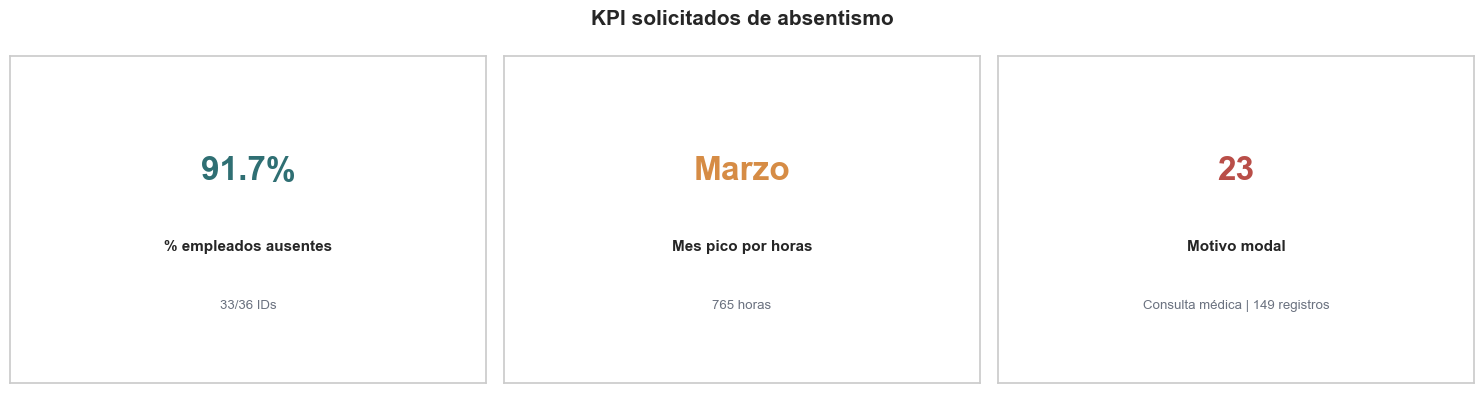

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("KPI solicitados de absentismo", fontsize=15, fontweight="bold")

tarjetas = [
    ["% empleados ausentes", f"{porcentaje_empleados_ausentes:.1f}%", f"{numero_ids_ausentes}/{numero_total_ids} IDs", COLOR_PRINCIPAL],
    ["Mes pico por horas", mes_pico_formula["Month_absence_name"], f"{mes_pico_formula['horas_absentismo']:.0f} horas", COLOR_SECUNDARIO],
    ["Motivo modal", str(int(motivo_modal_formula["Reason_absence"])), f"{motivo_modal_formula['Reason_absence_name']} | {int(motivo_modal_formula['frecuencia'])} registros", COLOR_ALERTA],
]

for ax, tarjeta in zip(axes, tarjetas):
    titulo, valor, detalle, color = tarjeta
    ax.set_facecolor("#F7F7F4")
    ax.text(0.5, 0.65, valor, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.42, titulo, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(0.5, 0.24, detalle, ha="center", va="center", fontsize=9.5, color=COLOR_GRIS)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none")
plt.show()


### Lectura de los KPI del enunciado

Estos KPI responden directamente a la pregunta semanal con los datos disponibles. 
El porcentaje muestra cuántos IDs del dataset tienen registros de ausencia, el mes pico permite revisar la planificación y el motivo modal identifica la causa más frecuente. 
Conviene mantener separados el **motivo modal por frecuencia** y el **motivo con más horas**, porque pueden responder a problemas distintos: recurrencia frente a severidad.


## 7. Variación mensual: ¿cuándo se concentra el absentismo?


In [7]:
absentismo_por_mes = df_temporal.groupby(
    ["Month_absence", "Month_absence_name"], as_index=False
).agg(
    empleados_unicos=("ID", "nunique"),
    registros_ausencia=("Tiene_ausencia", "sum"),
    horas_totales=("Absenteeism_hours", "sum"),
    horas_media=("Absenteeism_hours", "mean"),
    carga_media=("Work_load_Average_day", "mean"),
    hit_target_medio=("Hit_target", "mean"),
)

absentismo_por_mes = absentismo_por_mes.sort_values("Month_absence")
absentismo_por_mes["%_horas_anuales"] = absentismo_por_mes["horas_totales"] / absentismo_por_mes["horas_totales"].sum() * 100

absentismo_por_mes.round(2)


,Month_absence,Month_absence_name,empleados_unicos,registros_ausencia,horas_totales,horas_media,carga_media,hit_target_medio,%_horas_anuales
0,1.00,Enero,13,49,222,4.44,314.80,96.40,4.33
1,2.00,Febrero,19,72,294,4.08,270.21,97.21,5.74
2,3.00,Marzo,22,83,765,8.79,268.16,97.41,14.93
3,4.00,Abril,21,52,482,9.09,274.85,94.60,9.41
4,5.00,Mayo,24,58,400,6.25,275.07,97.25,7.81
5,6.00,Junio,19,51,411,7.61,298.01,95.06,8.02
6,7.00,Julio,23,65,734,10.96,249.81,95.03,14.32
7,8.00,Agosto,21,54,288,5.33,238.01,92.94,5.62
8,9.00,Septiembre,17,44,292,5.51,264.97,86.92,5.70
9,10.00,Octubre,19,62,349,4.92,269.07,90.32,6.81


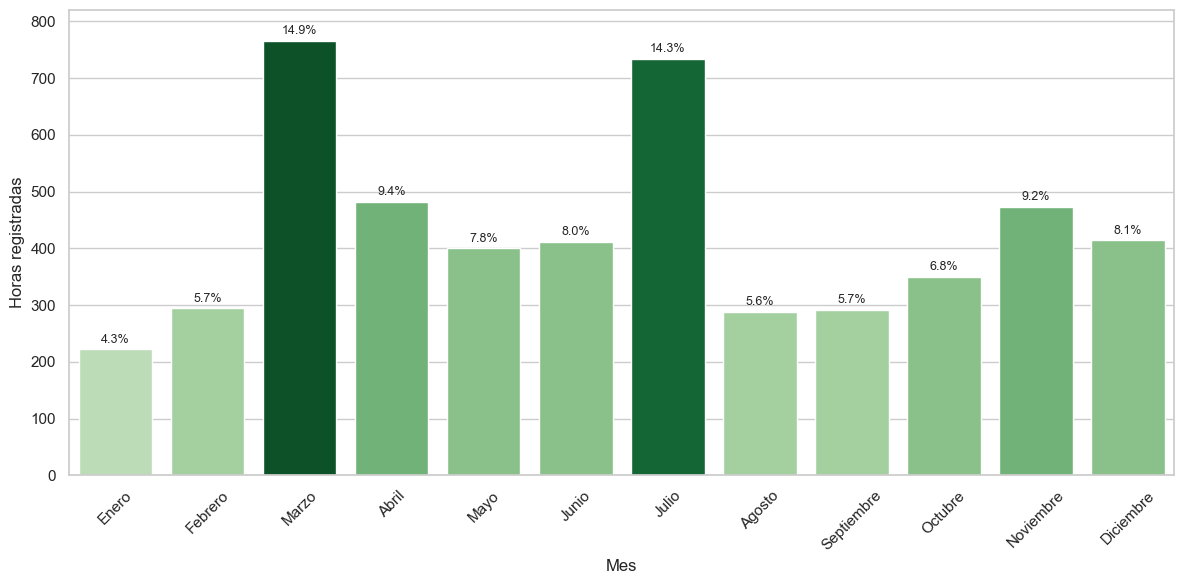

In [8]:
plot_data = absentismo_por_mes.copy()
plot_data["%_horas_absentismo"] = plot_data["horas_totales"] / plot_data["horas_totales"].sum() * 100

colores = sns.color_palette("Greens", n_colors=12)
colores_barras = [
    colores[int(valor / plot_data["horas_totales"].max() * 11)]
    for valor in plot_data["horas_totales"]
]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_data,
    x="Month_absence_name",
    y="horas_totales",
    hue="Month_absence_name",
    palette=colores_barras,
    legend=False,
    ax=ax
)

ax.set_xlabel("Mes")
ax.set_ylabel("Horas registradas")
ax.set_ylim(0, 820)
ax.set_yticks(range(0, 801, 100))
ax.tick_params(axis="x", rotation=45)

for i, fila in plot_data.iterrows():
    ax.text(
        i,
        fila["horas_totales"] + 12,
        f"{fila['%_horas_absentismo']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
fig.patch.set_alpha(0)
ax.set_facecolor("none")
plt.show()


### Conclusiones ejecutivas

**Magnitud de los registros:** hay **5124 horas registradas** y **696 registros con más de 0 horas**. El dataset contiene **36 IDs únicos**, de los cuales **33 (91.7%)** tienen al menos un registro de ausencia.

**Variación anual:** el mes con mayor carga registrada es **Marzo**, con **765 horas**, seguido de **Julio** con **734 horas**. Los tres meses de mayor presión son: **Marzo, Julio, Abril**.

**Motivos principales:** el motivo modal por frecuencia es **23 - Consulta médica**, con **149 registros**. En cambio, el motivo que más horas registradas acumula es **13 - Sistema musculoesquelético**, con **842 horas**.

**Planificación operativa:** el día con más horas registradas es **Lunes** y la estación con más horas es **Otoño**. Estos resultados sirven como primera aproximación para revisar la planificación, teniendo en cuenta que el dataset no confirma si las solicitudes fueron aprobadas.


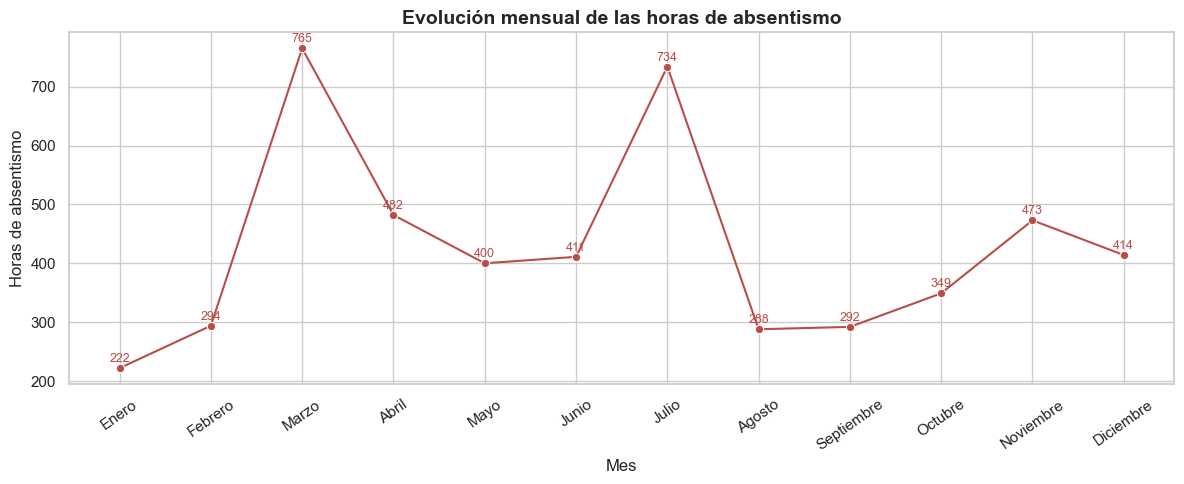

In [9]:
fig = plt.figure(figsize=(12, 5))
sns.lineplot(data=absentismo_por_mes, x="Month_absence_name", y="horas_totales", marker="o", color=COLOR_ALERTA)

plt.title("Evolución mensual de las horas de absentismo", fontsize=14, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Horas de absentismo")
plt.xticks(rotation=35)

for i, fila in absentismo_por_mes.iterrows():
    plt.text(i, fila["horas_totales"] + 10, f"{fila['horas_totales']:.0f}", ha="center", fontsize=9, color=COLOR_ALERTA)

plt.tight_layout()
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none")
plt.show()


### Lectura del gráfico

Este gráfico muestra únicamente la **evolución mensual de las horas registradas**. Los registros no se distribuyen de forma uniforme y presentan picos claros en marzo y julio. Es útil como vista limpia de tendencia cuando no queremos mezclar el análisis con otras métricas operativas.


## 8. Motivos de ausencia: ¿qué explica más horas?


In [10]:
absentismo_por_motivo = df_clean.groupby(
    ["Reason_absence", "Reason_absence_name"], as_index=False
).agg(
    registros=("ID", "count"),
    registros_ausencia=("Tiene_ausencia", "sum"),
    horas_totales=("Absenteeism_hours", "sum"),
    horas_media=("Absenteeism_hours", "mean"),
)

absentismo_por_motivo = absentismo_por_motivo.sort_values("horas_totales", ascending=False)
absentismo_por_motivo["%_horas"] = absentismo_por_motivo["horas_totales"] / absentismo_por_motivo["horas_totales"].sum() * 100

absentismo_por_motivo.round(2)


,Reason_absence,Reason_absence_name,registros,registros_ausencia,horas_totales,horas_media,%_horas
12,13.00,Sistema musculoesquelético,55,55,842,15.31,16.43
18,19.00,"Lesiones, intoxicaciones y consecuencias externas",40,40,729,18.23,14.23
21,23.00,Consulta médica,149,149,424,2.85,8.27
26,28.00,Consulta dental,112,112,335,2.99,6.54
10,11.00,Sistema digestivo,26,26,297,11.42,5.80
20,22.00,Seguimiento de paciente,38,38,293,7.71,5.72
9,10.00,Sistema respiratorio,25,25,276,11.04,5.39
24,26.00,Ausencia injustificada,33,33,240,7.27,4.68
17,18.00,Síntomas y hallazgos no clasificados,21,21,217,10.33,4.23
11,12.00,Piel y tejido subcutáneo,8,8,187,23.38,3.65


In [11]:
top_motivos = absentismo_por_motivo.sort_values("horas_totales", ascending=False).head(10).copy()
fig = px.scatter(
    top_motivos,
    x="registros_ausencia",
    y="horas_totales",
    size="horas_media",
    color="Reason_absence_name",
    text="Reason_absence",
    hover_name="Reason_absence_name",
    hover_data={
        "registros_ausencia": True,
        "horas_totales": ":.0f",
        "horas_media": ":.2f",
        "Reason_absence_name": False,
        "Reason_absence": False,
    },
    labels={
        "registros_ausencia": "Registros con ausencia",
        "horas_totales": "Horas totales",
        "horas_media": "Horas medias",
    },
    title="Motivos principales: frecuencia vs horas acumuladas",
)

fig.update_traces(textposition="middle center", textfont_color="white")
fig.update_layout(
    showlegend=False,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
)
fig.show()


### Lectura del gráfico

Este gráfico compara **frecuencia de registros** y **horas acumuladas** sin mezclar unidades en dos ejes. 
Los motivos situados más arriba acumulan más horas registradas; los situados más a la derecha aparecen más veces. 
El motivo **13 - Sistema musculoesquelético** destaca por horas acumuladas, mientras que el **23 - Consulta médica** destaca por frecuencia.


In [12]:
comparacion_motivos = absentismo_por_motivo[
    absentismo_por_motivo["Reason_absence"].isin([13, 23])
][["Reason_absence", "Reason_absence_name", "registros_ausencia", "horas_totales", "horas_media"]]

comparacion_motivos.round(2)


,Reason_absence,Reason_absence_name,registros_ausencia,horas_totales,horas_media
12,13.00,Sistema musculoesquelético,55,842,15.31
21,23.00,Consulta médica,149,424,2.85


### Lectura del gráfico

Este gráfico separa **frecuencia** y **severidad de los registros**. 
Algunos motivos aparecen muchas veces pero con pocas horas medias, como consultas médicas o dentales; otros aparecen menos, pero acumulan más horas. 
Esta distinción sirve como primera aproximación para revisar posibles medidas administrativas, preventivas o de cobertura.


## 9. Día de la semana y estación: señales para planificación


In [13]:
absentismo_por_dia = df_clean.groupby(
    ["Day_week", "Day_week_name"], as_index=False
).agg(
    registros=("ID", "count"),
    horas_totales=("Absenteeism_hours", "sum"),
    horas_media=("Absenteeism_hours", "mean"),
)
absentismo_por_dia = absentismo_por_dia.sort_values("Day_week")

absentismo_por_estacion = df_clean.groupby(
    ["Seasons", "Seasons_name"], as_index=False
).agg(
    registros=("ID", "count"),
    horas_totales=("Absenteeism_hours", "sum"),
    horas_media=("Absenteeism_hours", "mean"),
)
absentismo_por_estacion = absentismo_por_estacion.sort_values("Seasons")

print("Absentismo por día")
display(absentismo_por_dia.round(2))

print("Absentismo por estación")
display(absentismo_por_estacion.round(2))


Absentismo por día


,Day_week,Day_week_name,registros,horas_totales,horas_media
0,2,Lunes,161,1489,9.25
1,3,Martes,154,1229,7.98
2,4,Miércoles,156,1115,7.15
3,5,Jueves,125,553,4.42
4,6,Viernes,144,738,5.12


Absentismo por estación


,Seasons,Seasons_name,registros,horas_totales,horas_media
0,1,Invierno,170,1241,7.30
1,2,Primavera,195,1239,6.35
2,3,Verano,192,1152,6.00
3,4,Otoño,183,1492,8.15


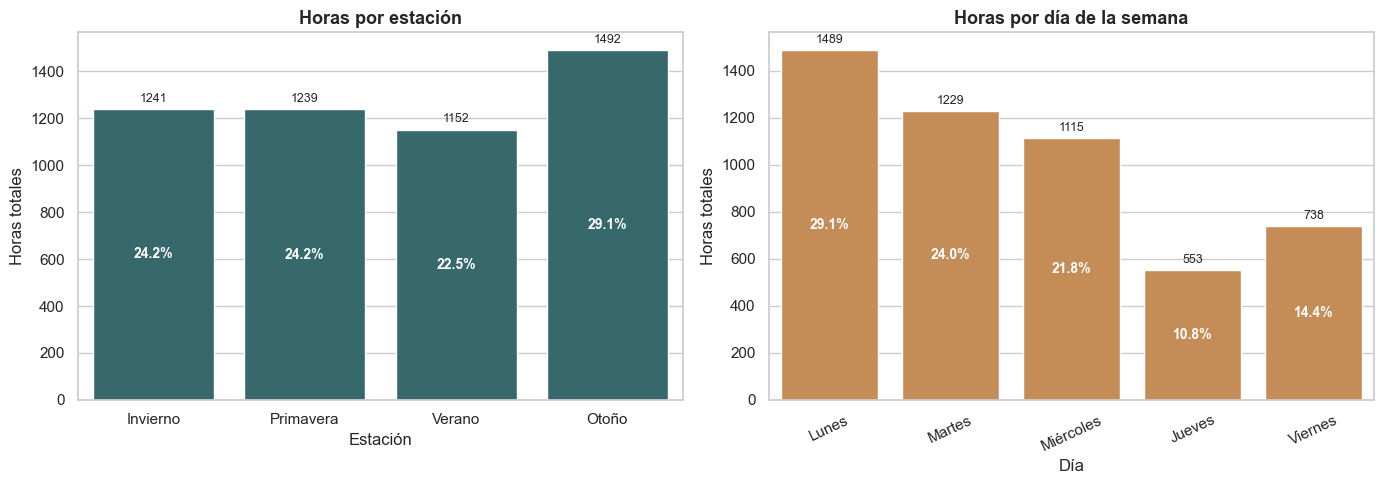

In [14]:

total_horas = df_clean["Absenteeism_hours"].sum()
absentismo_por_dia["%_horas"] = absentismo_por_dia["horas_totales"] / total_horas * 100
absentismo_por_estacion["%_horas"] = absentismo_por_estacion["horas_totales"] / total_horas * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=absentismo_por_estacion, x="Seasons_name", y="horas_totales", color=COLOR_PRINCIPAL, ax=axes[0])
axes[0].set_title("Horas por estación", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Estación")
axes[0].set_ylabel("Horas totales")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

for i, fila in absentismo_por_estacion.reset_index(drop=True).iterrows():
    axes[0].text(
        i,
        fila["horas_totales"] / 2,
        f"{fila['%_horas']:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

sns.barplot(data=absentismo_por_dia, x="Day_week_name", y="horas_totales", color=COLOR_SECUNDARIO, ax=axes[1])
axes[1].set_title("Horas por día de la semana", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Horas totales")
axes[1].tick_params(axis="x", rotation=25)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

for i, fila in absentismo_por_dia.reset_index(drop=True).iterrows():
    axes[1].text(
        i,
        fila["horas_totales"] / 2,
        f"{fila['%_horas']:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none")
plt.show()


### Lectura del gráfico

Estos gráficos ayudan a revisar posibles necesidades de cobertura. 
La cifra superior muestra las **horas registradas** y el porcentaje en blanco indica qué parte del total concentra cada día o estación. 
Los registros se concentran más en **lunes**, por lo que el inicio de semana merece especial atención en la planificación.


## 10. Concentración por empleado


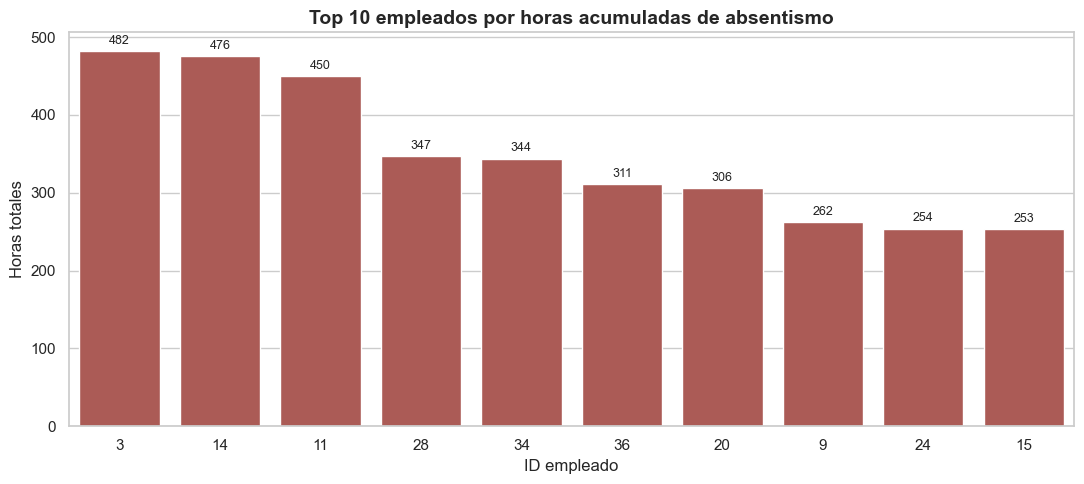

In [15]:
absentismo_por_empleado = df_clean.groupby("ID", as_index=False).agg(
    horas_totales=("Absenteeism_hours", "sum")
)
absentismo_por_empleado = absentismo_por_empleado.sort_values("horas_totales", ascending=False)
top_empleados = absentismo_por_empleado.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_empleados, x="ID", y="horas_totales", color=COLOR_ALERTA, order=top_empleados["ID"], ax=ax)
ax.set_title("Top 10 empleados por horas acumuladas de absentismo", fontsize=14, fontweight="bold")
ax.set_xlabel("ID empleado")
ax.set_ylabel("Horas totales")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none")
plt.show()


### Lectura del gráfico

Este gráfico responde a la **concentración de horas registradas por ID**. 
Los 10 IDs con más horas acumulan cerca del **68%** de las horas totales registradas, y los 5 primeros alrededor del **41%**. 
Para negocio, esto sugiere dos líneas de revisión distintas: planificación agregada para los picos temporales y revisión individual confidencial de los registros con carga acumulada alta.


## 11. Mapa de calor para planificación


In [16]:
prioridad_mes_dia = df_temporal.groupby(
    ["Month_absence", "Month_absence_name", "Day_week", "Day_week_name"],
    as_index=False
)["Absenteeism_hours"].sum()

prioridad_mes_dia = prioridad_mes_dia.rename(columns={"Absenteeism_hours": "horas_totales"})
prioridad_mes_dia["%_horas"] = prioridad_mes_dia["horas_totales"] / df_temporal["Absenteeism_hours"].sum() * 100

prioridad_mes_dia = prioridad_mes_dia.sort_values("%_horas", ascending=False)
prioridad_mes_dia.head(10).round(2)


,Month_absence,Month_absence_name,Day_week,Day_week_name,horas_totales,%_horas
31,7.00,Julio,3,Martes,325,6.34
56,12.00,Diciembre,3,Martes,275,5.37
10,3.00,Marzo,2,Lunes,262,5.11
50,11.00,Noviembre,2,Lunes,247,4.82
30,7.00,Julio,2,Lunes,236,4.61
17,4.00,Abril,4,Miércoles,234,4.57
11,3.00,Marzo,3,Martes,221,4.31
12,3.00,Marzo,4,Miércoles,128,2.50
27,6.00,Junio,4,Miércoles,127,2.48
22,5.00,Mayo,4,Miércoles,122,2.38


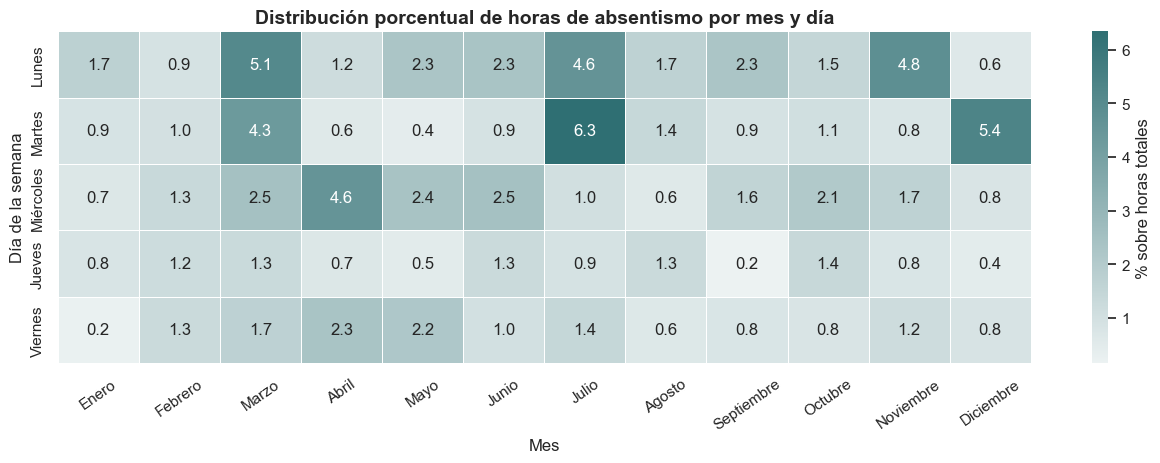

In [17]:
meses_orden = absentismo_por_mes["Month_absence_name"].tolist()
dias_orden = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"]

mapa_mes_dia = prioridad_mes_dia.pivot(
    index="Day_week_name",
    columns="Month_absence_name",
    values="%_horas"
)

mapa_mes_dia = mapa_mes_dia.reindex(index=dias_orden, columns=meses_orden).fillna(0)
paleta_heatmap = sns.light_palette(COLOR_PRINCIPAL, as_cmap=True)

fig = plt.figure(figsize=(13, 4.8))
sns.heatmap(
    mapa_mes_dia,
    annot=True,
    fmt=".1f",
    cmap=paleta_heatmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% sobre horas totales"}
)

plt.title("Distribución porcentual de horas de absentismo por mes y día", fontsize=14, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Día de la semana")
plt.xticks(rotation=35)
plt.tight_layout()
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none")
plt.show()


### Lectura del gráfico

Este mapa de calor responde mejor a la pregunta de **cómo anticiparse para reforzar la planificación**. 
No usa las horas absolutas como previsión directa, sino el **porcentaje de horas que concentra cada combinación de mes y día** dentro de los registros disponibles. 
Las celdas más oscuras indican momentos donde históricamente se registraron más horas y, por tanto, dónde tendría sentido revisar la cobertura, los turnos o las sustituciones si las solicitudes se confirman.


## 12. Respuesta a las preguntas de negocio

### Conclusiones ejecutivas

**Magnitud de los registros:** hay **5124 horas registradas** y **696 registros con más de 0 horas**. El dataset contiene **36 IDs únicos**, de los cuales **33 (91.7%)** tienen al menos un registro de ausencia.

**Variación anual:** el mes con mayor carga registrada es **Marzo**, con **765 horas**, seguido de **Julio** con **734 horas**. Los tres meses de mayor presión son: **Marzo, Julio, Abril**.

**Motivos principales:** el motivo modal por frecuencia es **23 - Consulta médica**, con **149 registros**. En cambio, el motivo que más horas registradas acumula es **13 - Sistema musculoesquelético**, con **842 horas**.

**Planificación operativa:** el día con más horas registradas es el **Lunes** y la estación que acumula más horas es **Otoño**. 
Estos resultados son una primera aproximación para revisar la planificación. El dataset no permite afirmar que las solicitudes fueron aprobadas ni calcular el absentismo efectivo total de la empresa.


## 13. Recomendaciones de negocio

1. **Revisar la cobertura antes de los meses pico:** marzo y julio concentran más horas registradas.
2. **Analizar los motivos de mayor impacto:** revisar prevención ergonómica y salud musculoesquelética, además de los registros de consultas médicas frecuentes.
3. **Separar seguimiento individual y planificación agregada:** los IDs con más horas acumuladas requieren una revisión confidencial de los registros; los picos mensuales permiten revisar necesidades de capacidad.
4. **Usar el mapa de calor como primera señal:** identificar cuándo se concentra un mayor porcentaje histórico de horas registradas.
5. **Validar los datos antes de calcular una tasa real:** hace falta conocer la plantilla completa y confirmar si las solicitudes fueron aprobadas.
